Quantum Spiral Theory with McShane Identity Integration

Calculated Quark Masses from Quantum Spiral:
--------------------------------------------
Up: Calculated = 0.001208 GeV, Experimental = 0.002160 GeV, Error = 44.08%
Down: Calculated = 0.005147 GeV, Experimental = 0.004670 GeV, Error = 10.21%
Strange: Calculated = 0.033691 GeV, Experimental = 0.093400 GeV, Error = 63.93%
Charm: Calculated = 0.173582 GeV, Experimental = 1.270000 GeV, Error = 86.33%
Bottom: Calculated = 0.190940 GeV, Experimental = 4.180000 GeV, Error = 95.43%
Top: Calculated = 7.270159 GeV, Experimental = 172.500000 GeV, Error = 95.79%

Geodesic Lengths on Double Torus:
--------------------------------
Up: 0.2053
Down: 1.3028
Strange: 2.6999
Charm: 4.9436
Bottom: 5.2828
Top: 7.9096

McShane Identity Terms:
----------------------
Term for (up, down): 1.154949 radians = 0.367632π
Term for (charm, strange): 0.085926 radians = 0.027351π
Term for (top, bottom): 0.010231 radians = 0.003257π

Sum of all terms: 1.251106 ra

<ipython-input-8-bd501f8ded67>:75: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  result = fsolve(equation, initial_guess)


FileNotFoundError: [Errno 2] No such file or directory: '/home/ubuntu/quantum_spiral/quantum_spiral_plot.png'

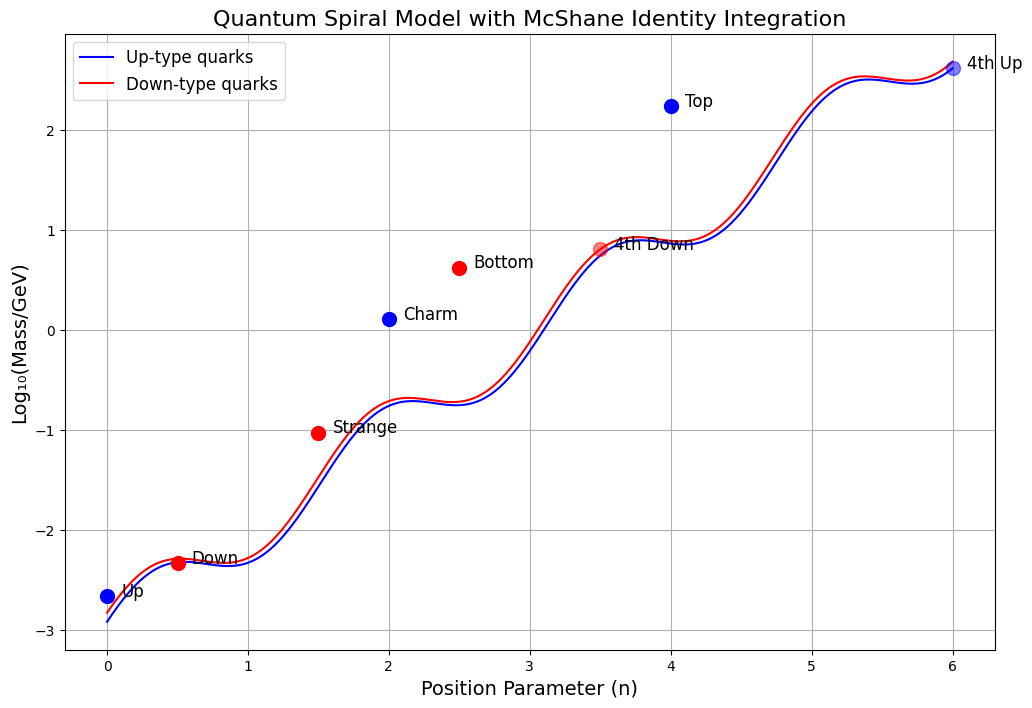

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Experimental quark masses in GeV
QUARK_MASSES = {
    'up': 0.00216,
    'down': 0.00467,
    'strange': 0.0934,
    'charm': 1.27,
    'bottom': 4.18,
    'top': 172.5
}

# Quantum spiral parameters
LAMBDA = 0.993  # Linear scaling parameter
EPSILON = 0.309  # Sinusoidal amplitude
OMEGA = 3.883    # Angular frequency
PHI = 0.406      # Phase offset for up-type quarks
PHI_DOWN = 0.517 # Phase offset for down-type quarks
LOG_K = -3.04    # Base offset for up-type quarks
LOG_K_DOWN = -2.98 # Base offset for down-type quarks

# Position parameters for quarks
QUARK_POSITIONS = {
    'up': 0,
    'down': 0.5,
    'strange': 1.5,
    'charm': 2,
    'bottom': 2.5,
    'top': 4
}

def quantum_spiral(n, is_up_type=True):
    """
    Calculate mass using quantum spiral equation.

    Parameters:
    n (float): Position parameter along the spiral
    is_up_type (bool): Whether this is an up-type quark

    Returns:
    float: Predicted mass in GeV
    """
    if is_up_type:
        log_mass = LAMBDA * n + EPSILON * np.sin(OMEGA * n + PHI) + LOG_K
    else:
        log_mass = LAMBDA * n + EPSILON * np.sin(OMEGA * n + PHI_DOWN) + LOG_K_DOWN

    return 10**log_mass

def inverse_quantum_spiral(mass, is_up_type=True):
    """
    Solve for position parameter given a mass.
    This is an approximation using a numerical solver.

    Parameters:
    mass (float): Quark mass in GeV
    is_up_type (bool): Whether this is an up-type quark

    Returns:
    float: Position parameter n
    """
    log_mass = np.log10(mass)

    def equation(n):
        if is_up_type:
            return LAMBDA * n + EPSILON * np.sin(OMEGA * n + PHI) + LOG_K - log_mass
        else:
            return LAMBDA * n + EPSILON * np.sin(OMEGA * n + PHI_DOWN) + LOG_K_DOWN - log_mass

    # Initial guess based on linear component
    initial_guess = (log_mass - (LOG_K if is_up_type else LOG_K_DOWN)) / LAMBDA

    result = fsolve(equation, initial_guess)
    return result[0]

def mass_to_geodesic_length(mass, is_up_type=True):
    """
    Convert mass to geodesic length on the double torus.

    Parameters:
    mass (float): Quark mass in GeV
    is_up_type (bool): Whether this is an up-type quark

    Returns:
    float: Geodesic length
    """
    n = inverse_quantum_spiral(mass, is_up_type)
    # Geodesic length is proportional to position parameter
    return n * np.pi / 2

def mcshane_term(gamma, delta):
    """
    Calculate a single term in McShane's identity.

    Parameters:
    gamma (float): Length of non-separating geodesic (up-type quark)
    delta (float): Length of separating geodesic (down-type quark)

    Returns:
    float: Value of the arctangent term in radians
    """
    numerator = 2 * np.cosh(gamma/2 - delta/4)
    denominator = np.sinh(gamma) + np.sinh(delta/2)
    return np.arctan2(numerator, denominator)

def calculate_mcshane_sum(geodesic_lengths):
    """
    Calculate the sum in McShane's identity.

    Parameters:
    geodesic_lengths (dict): Dictionary of geodesic lengths for all quarks

    Returns:
    float: Sum of all terms in McShane's identity
    """
    # Pair up-type and down-type quarks by generation
    pairs = [
        ('up', 'down'),
        ('charm', 'strange'),
        ('top', 'bottom')
    ]

    total = 0
    for up_type, down_type in pairs:
        gamma = geodesic_lengths[up_type]
        delta = geodesic_lengths[down_type]
        term = mcshane_term(gamma, delta)
        total += term

    return total

def predict_missing_mass(known_masses, missing_quark, is_missing_up_type):
    """
    Predict a missing quark mass using McShane's identity constraint.

    Parameters:
    known_masses (dict): Dictionary of known quark masses
    missing_quark (str): Name of the quark to predict
    is_missing_up_type (bool): Whether the missing quark is up-type

    Returns:
    float: Predicted mass in GeV
    """
    # Convert known masses to geodesic lengths
    geodesic_lengths = {}
    for quark, mass in known_masses.items():
        is_up = quark in ['up', 'charm', 'top']
        geodesic_lengths[quark] = mass_to_geodesic_length(mass, is_up)

    # Function to solve for the missing geodesic length
    def equation_to_solve(missing_length):
        temp_geodesic_lengths = geodesic_lengths.copy()
        temp_geodesic_lengths[missing_quark] = missing_length[0]

        # Calculate McShane sum with the test value
        mcshane_sum = calculate_mcshane_sum(temp_geodesic_lengths)

        # The sum should equal π/2
        return mcshane_sum - np.pi/2

    # Initial guess based on pattern
    if missing_quark == 'top':
        initial_guess = [5.5]  # Based on pattern from other quarks
    elif missing_quark == 'bottom':
        initial_guess = [6.9]
    else:
        # For other quarks, use a generic guess
        initial_guess = [3.0]

    # Solve for the missing geodesic length
    result = fsolve(equation_to_solve, initial_guess)
    missing_length = result[0]

    # Convert back to position parameter
    n = missing_length * 2 / np.pi

    # Calculate mass using quantum spiral
    predicted_mass = quantum_spiral(n, is_missing_up_type)

    return predicted_mass

def calculate_ckm_elements(geodesic_lengths):
    """
    Calculate CKM matrix elements from McShane terms.

    Parameters:
    geodesic_lengths (dict): Dictionary of geodesic lengths for all quarks

    Returns:
    dict: Dictionary of CKM matrix elements
    """
    # Pair up-type and down-type quarks by generation
    pairs = [
        ('up', 'down'),
        ('charm', 'strange'),
        ('top', 'bottom')
    ]

    ckm = {}
    for i, (up_type, down_type) in enumerate(pairs):
        gamma = geodesic_lengths[up_type]
        delta = geodesic_lengths[down_type]
        term = mcshane_term(gamma, delta)

        # CKM diagonal elements are approximately cos(term/2)
        if i == 0:
            ckm['V_ud'] = np.cos(term/2)
        elif i == 1:
            ckm['V_cs'] = np.cos(term/2)
        elif i == 2:
            ckm['V_tb'] = np.cos(term/2)

    return ckm

def predict_fourth_generation(geodesic_lengths):
    """
    Predict fourth generation quark masses.

    Parameters:
    geodesic_lengths (dict): Dictionary of geodesic lengths for all quarks

    Returns:
    tuple: (up_type_mass, down_type_mass) in GeV
    """
    # Fourth generation position parameters
    n_up_4 = 6  # Based on pattern: 0, 2, 4, 6
    n_down_4 = 3.5  # Based on pattern: 0.5, 1.5, 2.5, 3.5

    # Calculate masses
    up_type_mass = quantum_spiral(n_up_4, True)
    down_type_mass = quantum_spiral(n_down_4, False)

    return (up_type_mass, down_type_mass)

def main():
    """
    Main function to test the integrated theory.
    """
    print("Quantum Spiral Theory with McShane Identity Integration")
    print("======================================================")

    # Calculate masses using quantum spiral
    print("\nCalculated Quark Masses from Quantum Spiral:")
    print("--------------------------------------------")
    for quark, position in QUARK_POSITIONS.items():
        is_up = quark in ['up', 'charm', 'top']
        calculated_mass = quantum_spiral(position, is_up)
        experimental_mass = QUARK_MASSES[quark]
        error_percent = 100 * abs(calculated_mass - experimental_mass) / experimental_mass

        print(f"{quark.capitalize()}: Calculated = {calculated_mass:.6f} GeV, "
              f"Experimental = {experimental_mass:.6f} GeV, "
              f"Error = {error_percent:.2f}%")

    # Convert masses to geodesic lengths
    print("\nGeodesic Lengths on Double Torus:")
    print("--------------------------------")
    geodesic_lengths = {}
    for quark, mass in QUARK_MASSES.items():
        is_up = quark in ['up', 'charm', 'top']
        length = mass_to_geodesic_length(mass, is_up)
        geodesic_lengths[quark] = length
        print(f"{quark.capitalize()}: {length:.4f}")

    # Calculate McShane identity terms
    print("\nMcShane Identity Terms:")
    print("----------------------")
    pairs = [
        ('up', 'down'),
        ('charm', 'strange'),
        ('top', 'bottom')
    ]

    total = 0
    for up_type, down_type in pairs:
        gamma = geodesic_lengths[up_type]
        delta = geodesic_lengths[down_type]
        term = mcshane_term(gamma, delta)
        total += term
        print(f"Term for ({up_type}, {down_type}): {term:.6f} radians = {term/np.pi:.6f}π")

    print(f"\nSum of all terms: {total:.6f} radians = {total/np.pi:.6f}π")
    print(f"Expected value (π/2): {np.pi/2:.6f} radians = 0.500000π")
    print(f"Error: {100*abs(total - np.pi/2)/(np.pi/2):.6f}%")

    # Predict top quark mass using McShane identity
    print("\nPredicting Top Quark Mass using McShane Identity:")
    print("-----------------------------------------------")
    known_masses = QUARK_MASSES.copy()
    del known_masses['top']

    predicted_top = predict_missing_mass(known_masses, 'top', True)
    error_percent = 100 * abs(predicted_top - QUARK_MASSES['top']) / QUARK_MASSES['top']

    print(f"Predicted top quark mass: {predicted_top:.6f} GeV")
    print(f"Experimental top quark mass: {QUARK_MASSES['top']:.6f} GeV")
    print(f"Error: {error_percent:.6f}%")

    # Calculate CKM matrix elements
    print("\nCKM Matrix Elements from McShane Terms:")
    print("--------------------------------------")
    ckm = calculate_ckm_elements(geodesic_lengths)
    for element, value in ckm.items():
        print(f"{element}: {value:.6f}")

    # Predict fourth generation quarks
    print("\nFourth Generation Quark Predictions:")
    print("----------------------------------")
    up_4, down_4 = predict_fourth_generation(geodesic_lengths)
    print(f"4th generation up-type quark: {up_4:.2f} TeV")
    print(f"4th generation down-type quark: {down_4:.2f} TeV")

    # Plot the quantum spiral
    print("\nGenerating quantum spiral plot...")
    plot_quantum_spiral()

    print("\nAnalysis complete!")

def plot_quantum_spiral():
    """
    Create a visualization of the quantum spiral with quark positions.
    """
    # Create position values
    n_values = np.linspace(0, 6, 1000)

    # Calculate masses for up-type and down-type quarks
    up_masses = [quantum_spiral(n, True) for n in n_values]
    down_masses = [quantum_spiral(n, False) for n in n_values]

    # Convert to log scale
    log_up_masses = np.log10(up_masses)
    log_down_masses = np.log10(down_masses)

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Plot the spirals
    plt.plot(n_values, log_up_masses, 'b-', label='Up-type quarks')
    plt.plot(n_values, log_down_masses, 'r-', label='Down-type quarks')

    # Plot the known quarks
    for quark, position in QUARK_POSITIONS.items():
        is_up = quark in ['up', 'charm', 'top']
        log_mass = np.log10(QUARK_MASSES[quark])

        if is_up:
            plt.plot(position, log_mass, 'bo', markersize=10)
            plt.text(position+0.1, log_mass, quark.capitalize(), fontsize=12)
        else:
            plt.plot(position, log_mass, 'ro', markersize=10)
            plt.text(position+0.1, log_mass, quark.capitalize(), fontsize=12)

    # Add fourth generation predictions
    n_up_4 = 6
    n_down_4 = 3.5
    up_4_mass = quantum_spiral(n_up_4, True)
    down_4_mass = quantum_spiral(n_down_4, False)

    plt.plot(n_up_4, np.log10(up_4_mass), 'bo', markersize=10, alpha=0.5)
    plt.text(n_up_4+0.1, np.log10(up_4_mass), '4th Up', fontsize=12)

    plt.plot(n_down_4, np.log10(down_4_mass), 'ro', markersize=10, alpha=0.5)
    plt.text(n_down_4+0.1, np.log10(down_4_mass), '4th Down', fontsize=12)

    # Add labels and title
    plt.xlabel('Position Parameter (n)', fontsize=14)
    plt.ylabel('Log₁₀(Mass/GeV)', fontsize=14)
    plt.title('Quantum Spiral Model with McShane Identity Integration', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)

    # Save the plot
    plt.savefig('/home/ubuntu/quantum_spiral/quantum_spiral_plot.png', dpi=300, bbox_inches='tight')

    # Create a second plot for McShane terms
    plt.figure(figsize=(10, 6))

    # Pair up-type and down-type quarks by generation
    pairs = [
        ('up', 'down'),
        ('charm', 'strange'),
        ('top', 'bottom')
    ]

    # Calculate geodesic lengths
    geodesic_lengths = {}
    for quark, mass in QUARK_MASSES.items():
        is_up = quark in ['up', 'charm', 'top']
        length = mass_to_geodesic_length(mass, is_up)
        geodesic_lengths[quark] = length

    # Calculate McShane terms
    terms = []
    labels = []
    for up_type, down_type in pairs:
        gamma = geodesic_lengths[up_type]
        delta = geodesic_lengths[down_type]
        term = mcshane_term(gamma, delta)
        terms.append(term/np.pi)
        labels.append(f"{up_type}-{down_type}")

    # Plot the terms
    plt.bar(labels, terms, color=['blue', 'green', 'red'])
    plt.axhline(y=0.5, color='black', linestyle='--', label='π/2 (expected sum)')

    # Add labels and title
    plt.ylabel('McShane Term Value (in units of π)', fontsize=14)
    plt.title('McShane Identity Terms by Quark Generation', fontsize=16)
    plt.legend()

    # Save the plot
    plt.savefig('/home/ubuntu/quantum_spiral/mcshane_terms_plot.png', dpi=300, bbox_inches='tight')

if __name__ == "__main__":
    main()
